In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

# Reading the datasets 

In [2]:
df = pd.read_csv('height-weight.csv')
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


In [3]:
df.shape

(23, 2)

# Visualising the data

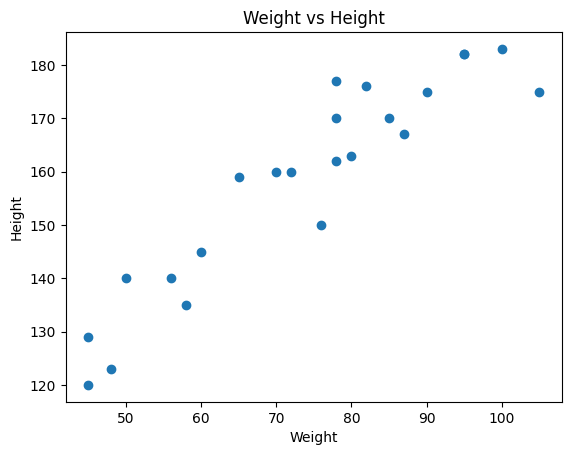

In [4]:
plt.scatter(df['Weight'],df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')
plt.title('Weight vs Height')
plt.show()

# Dividing the dataset into train and test

In [5]:
X = df['Height'].values
Y = df['Weight'].values

In [6]:
X

array([120, 135, 123, 145, 160, 162, 163, 175, 182, 170, 176, 182, 175,
       183, 170, 177, 140, 159, 150, 167, 129, 140, 160])

In [8]:
Y

array([ 45,  58,  48,  60,  70,  78,  80,  90,  95,  78,  82,  95, 105,
       100,  85,  78,  50,  65,  76,  87,  45,  56,  72])

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [11]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape


((18,), (5,), (18,), (5,))

In [12]:
from sklearn.preprocessing import StandardScaler

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.reshape(-1,1))
X_test_scaled = scaler.transform(X_test.reshape(-1,1))


# visualising the x_train vs y-train and x_test vs y_test

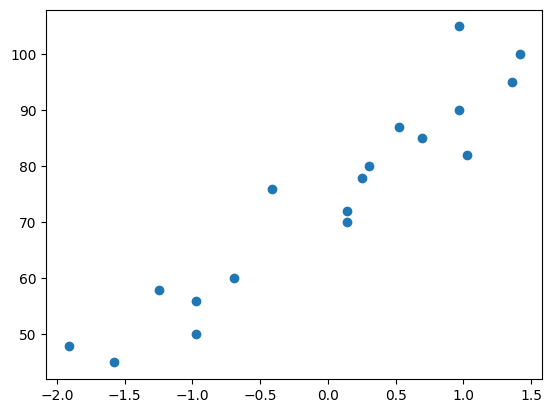

In [14]:
plt.scatter(X_train_scaled,y_train)

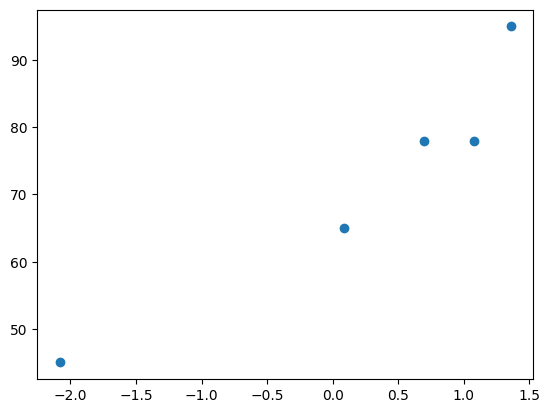

In [15]:
plt.scatter(X_test_scaled, y_test)

# Training the model


In [16]:
from sklearn.linear_model import LinearRegression

In [17]:
regressor = LinearRegression()

In [18]:
regressor.fit(X_train_scaled,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [19]:
## coefficient and intercepts
print("Coefficient : ",regressor.coef_)
print("Intercept : ",regressor.intercept_)

Coefficient :  [16.71556824]
Intercept :  74.27777777777777


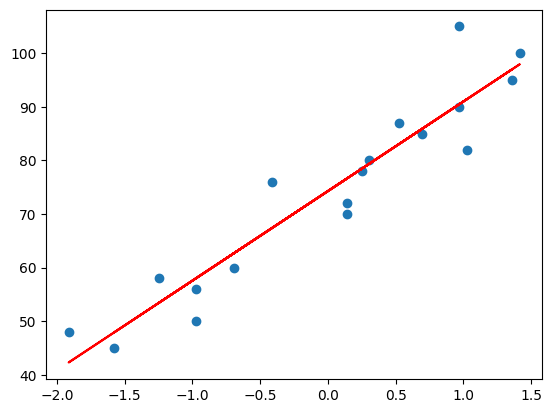

In [20]:
plt.scatter(X_train_scaled,y_train)
plt.plot(X_train_scaled, regressor.predict(X_train_scaled), color='red')

In [21]:
y_pred = regressor.predict(X_test_scaled)

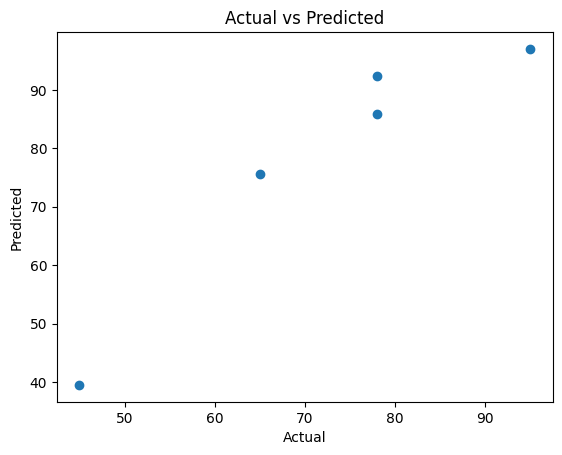

In [22]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

# Performances metrics

In [23]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error: ", mse)
print("Mean Absolute Error: ", mae)
print("R^2 Score: ", r2)

Mean Squared Error:  83.23803021031193
Mean Absolute Error:  8.0787039411815
R^2 Score:  0.6981504561563971


In [24]:
#display adjusted R-squared
adj_r2 = 1 - (1 - r2) * (len(y_test) - 1) / (len(y_test) - X_test_scaled.shape[1] - 1)
print("Adjusted R^2 Score: ", adj_r2)


Adjusted R^2 Score:  0.5975339415418628


# Check assumption
1. plot between y-test and y_pred should be linear
2. residuals = y_pred - y_test should be nearly equal to zero or normally distributed
3. Scatter plot between Y_pred and residuals should be uniform distribution i.e.. it should have value in both positive and negaitve region so that the total residuals comes out to near to zero

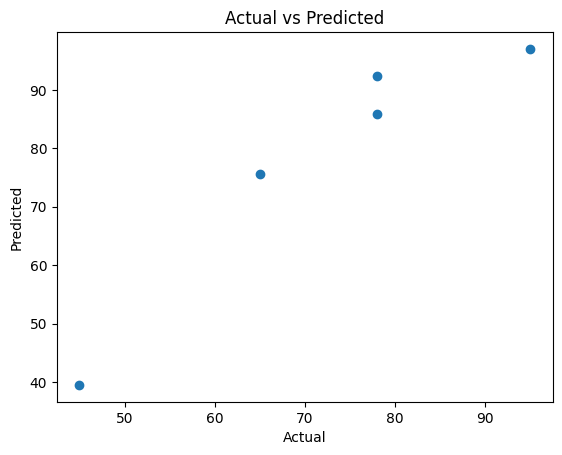

In [25]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()


In [26]:
y_test

array([78, 78, 45, 95, 65])

# SLR regression analysis

In [28]:
import statsmodels.api as sm
model = sm.OLS(y_train, X_train_scaled).fit()
results = model.predict(X_test_scaled)

In [30]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.048
Model:                            OLS   Adj. R-squared (uncentered):             -0.008
Method:                 Least Squares   F-statistic:                             0.8558
Date:                Sat, 14 Mar 2026   Prob (F-statistic):                       0.368
Time:                        12:22:42   Log-Likelihood:                         -103.14
No. Observations:                  18   AIC:                                      208.3
Df Residuals:                      17   BIC:                                      209.2
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------